## Mori Model

(2.1) from Hughes et al. 2024

$\frac{\partial u}{\partial t}=(b+\gamma\frac{u^n}{1+u^n})v-Iu+D\frac{\partial^2u}{\partial x^2}$

$\frac{\partial v}{\partial t}=-(b+\gamma\frac{u^n}{1+u^n})v+Iu+\frac{\partial^2v}{\partial x^2}$

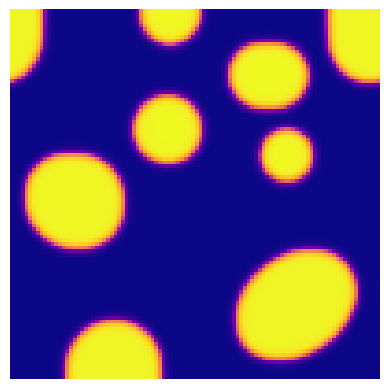

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
from pde_utils import laplacian

# set random seed
np.random.seed(42)

# define parameters
Da = 0.1 # A diffusion rate
Db = 10 # B diffusion rate
delta = 1 # basal rate of inactivation
gamma = 1.0 # GTPase autocatalytic activation rate
K = 1 # saturation parameter
k0 = 0.067 # basal GEF conversion rate
L = 10 # cell diameter (µm)

size = 100 # number of cells
dt = 0.01  # time step
t = 2000.0 # run time
frame_int = 5 # animation frame interval

# set initial concentrations
A =  2 * 0.2683312 * np.random.rand(size, size)
B = np.full((size,size), 2.0)

# define reaction kinetics function
def f(a, b):
    return (k0 + gamma*a**2/(K**2 + a**2))*b - delta*a

# set up figure
fig, ax = plt.subplots()
ax.axis('off')
frames = []

# simulate the PDE with finite difference method
for i in range(int(t/dt)):

    # update concentrations
    A = A + dt * (Da * laplacian(A) + f(A, B))
    B = B + dt * (Db * laplacian(B) - f(A, B))

    # apply Neumann boundary conditions
    for Z in (A, B):
        Z[0] = Z[1]
        Z[-1] = Z[-2]

    # capture a frame every frame_int seconds
    if i % 5000 == 0:
        frame = [ax.imshow(A.copy(), cmap='plasma', animated=True)]
        frames.append(frame)

animation.ArtistAnimation(fig, frames, interval=100, blit=True).save('animations/mori_2D.gif', writer=PillowWriter(fps=10))